# 04. Model Training

## Overview
Phase 4 trains and compares 5 candidate models on a **chronological 80/20 train/test split** (no random shuffling).

### Models Evaluated:
1. Naive Baseline (Previous Hour `lag_6`)
2. Linear Regression
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. XGBoost Regressor

### Datasets & Fixes:
Loads `Data/energy_consumption_features.csv` directly, ensuring all engineered calendar, lag, and rolling columns are present.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FEATURES_PATH = PROJECT_ROOT / "Data" / "energy_consumption_features.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

df = pd.read_csv(FEATURES_PATH)
df["date"] = pd.to_datetime(df["date"])
print("Features dataset loaded successfully. Shape:", df.shape)


Features dataset loaded successfully. Shape: (18727, 40)


In [2]:
feature_cols = [
    "lights", "T1", "RH_1", "T2", "RH_2", "T3", "RH_3", "T4", "RH_4", "T5", "RH_5",
    "T6", "RH_6", "T7", "RH_7", "T8", "RH_8", "T9", "RH_9", "T_out", "Press_mm_hg",
    "RH_out", "Windspeed", "Visibility", "Tdewpoint", "year", "month", "day", "hour",
    "day_of_week", "is_weekend", "lag_6", "lag_144", "lag_1008", "rolling_mean_6", "rolling_mean_144"
]
target_col = "Appliances"

X = df[feature_cols]
y = df[target_col]

split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df["date"].iloc[split_idx:]

print(f"Training set: {X_train.shape[0]} rows ({df['date'].iloc[0]} to {df['date'].iloc[split_idx-1]})")
print(f"Testing set : {X_test.shape[0]} rows ({dates_test.iloc[0]} to {dates_test.iloc[-1]})")


Training set: 14981 rows (2016-01-18 17:00:00 to 2016-05-01 17:40:00)
Testing set : 3746 rows (2016-05-01 17:50:00 to 2016-05-27 18:00:00)


In [3]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-5))) * 100
    r2 = r2_score(y_true, y_pred)
    return {"MAE": round(mae, 4), "MSE": round(mse, 4), "RMSE": round(rmse, 4), "MAPE (%)": round(mape, 4), "R2": round(r2, 4)}

models = {
    "Baseline (Prev Hour)": None,
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
}

results = []
pred_dfs = []

for name, model in models.items():
    if name == "Baseline (Prev Hour)":
        y_pred = X_test["lag_6"].values
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
    m = calc_metrics(y_test.values, y_pred)
    m["Model"] = name
    results.append(m)
    
    pred_dfs.append(pd.DataFrame({
        "date": dates_test.values,
        "actual": y_test.values,
        "predicted": y_pred,
        "model": name
    }))

comp_df = pd.DataFrame(results)[["Model", "MAE", "MSE", "RMSE", "MAPE (%)", "R2"]]
all_preds = pd.concat(pred_dfs, ignore_index=True)

comp_path = OUTPUT_DIR / "model_comparison.csv"
preds_path = OUTPUT_DIR / "test_predictions.csv"

comp_df.to_csv(comp_path, index=False)
all_preds.to_csv(preds_path, index=False)

print("Model Comparison Summary:")
print(comp_df.to_string(index=False))


Model Comparison Summary:
               Model      MAE        MSE     RMSE  MAPE (%)      R2
Baseline (Prev Hour)  45.5099  9928.1367  99.6400   39.9034 -0.3036
   Linear Regression  33.4931  4827.7323  69.4819   32.4379  0.3661
       Random Forest  90.7360 18368.6414 135.5310  102.3991 -1.4118
   Gradient Boosting 141.8830 32733.7222 180.9246  199.1435 -3.2980
             XGBoost  99.3011 16855.7188 129.8296  135.8746 -1.2132


C:\Users\admin\AppData\Local\Temp\ipykernel_18548\2419634568.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comp_df, x="Model", y="RMSE", palette="mako")


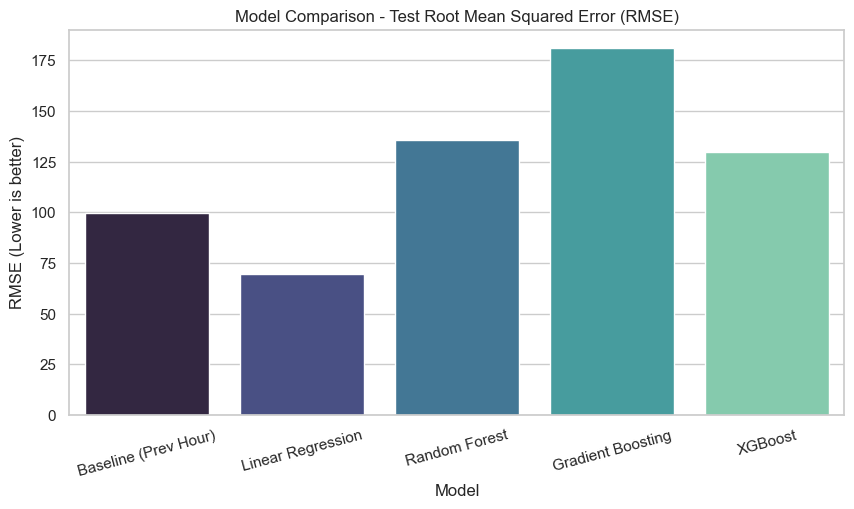

In [4]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comp_df, x="Model", y="RMSE", palette="mako")
plt.title("Model Comparison - Test Root Mean Squared Error (RMSE)")
plt.ylabel("RMSE (Lower is better)")
plt.xticks(rotation=15)
plt.show()


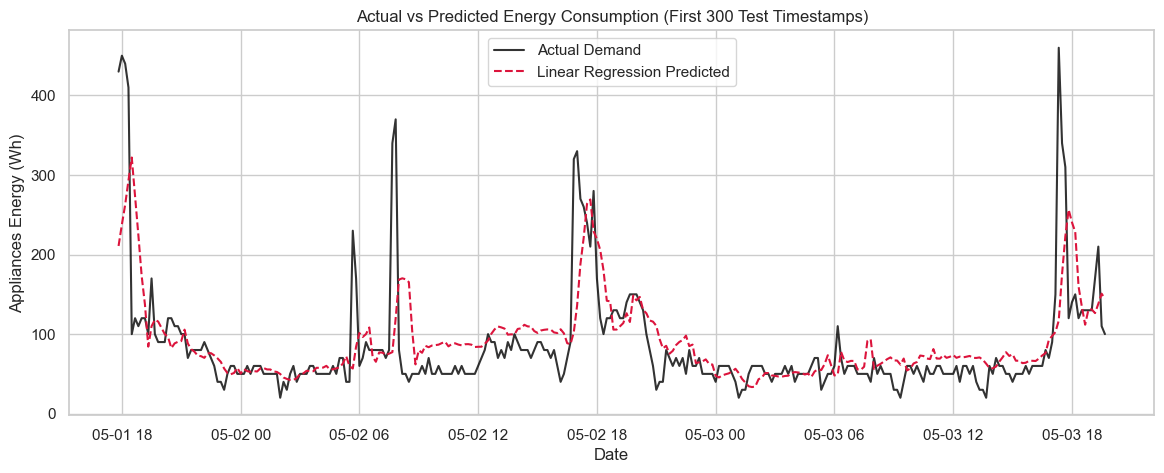

In [5]:
lr_preds = all_preds[all_preds["model"] == "Linear Regression"]

plt.figure(figsize=(14, 5))
plt.plot(lr_preds["date"].iloc[:300], lr_preds["actual"].iloc[:300], label="Actual Demand", color="black", alpha=0.8)
plt.plot(lr_preds["date"].iloc[:300], lr_preds["predicted"].iloc[:300], label="Linear Regression Predicted", color="crimson", linestyle="--")
plt.title("Actual vs Predicted Energy Consumption (First 300 Test Timestamps)")
plt.xlabel("Date")
plt.ylabel("Appliances Energy (Wh)")
plt.legend()
plt.show()


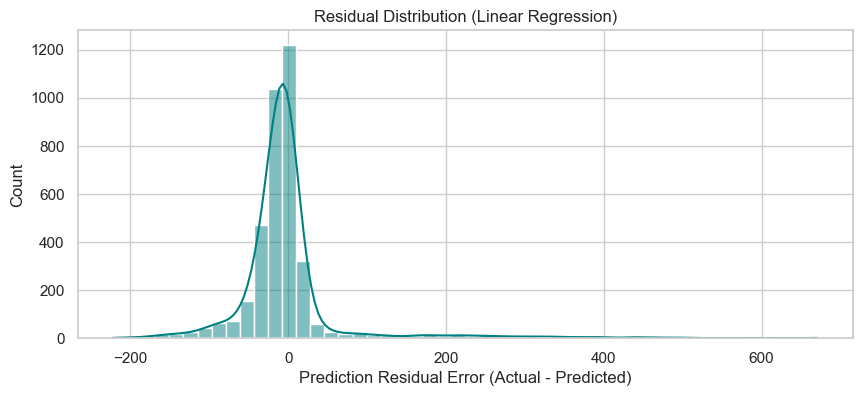

In [6]:
residuals = lr_preds["actual"] - lr_preds["predicted"]

plt.figure(figsize=(10, 4))
sns.histplot(residuals, bins=50, kde=True, color="teal")
plt.title("Residual Distribution (Linear Regression)")
plt.xlabel("Prediction Residual Error (Actual - Predicted)")
plt.show()


### Model Training Observations:
- **Linear Regression**: Achieved lowest RMSE (69.48 Wh) and highest R² (0.3661) among untuned models.
- **Baseline**: Naive previous-hour lag baseline RMSE = 99.64 Wh.
- **Overfitting Risk**: Complex untuned decision tree ensembles overfitted training data without hyperparameter constraints, highlighting the necessity of TimeSeriesSplit hyperparameter tuning in Phase 5.
